# 04: Calibration, Confidence Logic, and Clinical Review Gates

A clinical AI system cannot rely on discrimination metrics alone. For clinician-facing decision support, probabilities need calibration, uncertainty, confidence logic, and escalation rules.

This notebook adds:

- calibrated probability comparison
- Brier score and expected calibration error
- bootstrap prediction intervals
- missingness-aware confidence logic
- indeterminate/clinician-review gates

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from proteomics_index.modeling import make_baseline_models, binary_metrics
from proteomics_index.confidence import (
    calibration_summary,
    bootstrap_prediction_intervals,
    missingness_penalty,
    confidence_score_from_signals,
    confidence_label,
)
from proteomics_index.scoring import compute_index_table

DATA_PROCESSED = ROOT / "data" / "processed"
REPORTS = ROOT / "reports"
REPORTS.mkdir(exist_ok=True)

## 1. Load data and split into train/calibration/test sets

In [2]:
X_raw = pd.read_csv(DATA_PROCESSED / "X_proteomics.csv")
X = X_raw.set_index("SampleID") if "SampleID" in X_raw.columns else X_raw
y_raw = pd.read_csv(DATA_PROCESSED / "y_severe_outcome.csv")
y = y_raw.set_index("SampleID")["SevereOutcome"].loc[X.index] if "SampleID" in y_raw.columns else y_raw.squeeze("columns")

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=7
)
X_train, X_cal, y_train, y_cal = train_test_split(
    X_train_full, y_train_full, test_size=0.30, stratify=y_train_full, random_state=7
)

print(X_train.shape, X_cal.shape, X_test.shape)
print("Train/cal/test event rates:", round(y_train.mean(), 2), round(y_cal.mean(), 2), round(y_test.mean(), 2))

(50, 240) (22, 240) (24, 240)
Train/cal/test event rates: 0.16 0.18 0.17


## 2. Fit base model and calibrated model

In [3]:
base_model = make_baseline_models(k_features=40, random_state=7)["ElasticNet_LogReg"]
base_model.fit(X_train_full, y_train_full)

# CalibratedClassifierCV is fitted with internal CV for compatibility across scikit-learn versions.
# In a locked clinical validation protocol, calibration data and tuning rules would be pre-specified.
calibrated_model = CalibratedClassifierCV(
    make_baseline_models(k_features=40, random_state=7)["ElasticNet_LogReg"],
    method="sigmoid",
    cv=3,
)
calibrated_model.fit(X_train_full, y_train_full)

base_prob = base_model.predict_proba(X_test)[:, 1]
cal_prob = calibrated_model.predict_proba(X_test)[:, 1]

comparison = pd.DataFrame([
    {"model": "base", **binary_metrics(y_test, base_prob), **{k:v for k,v in calibration_summary(y_test, base_prob).items() if k != "calibration_bins"}},
    {"model": "calibrated", **binary_metrics(y_test, cal_prob), **{k:v for k,v in calibration_summary(y_test, cal_prob).items() if k != "calibration_bins"}},
])
comparison.to_csv(REPORTS / "calibration_validation_metrics.csv", index=False)
comparison

/opt/pyvenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/pyvenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/pyvenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to

,model,AUROC,AUPRC,Brier,Sensitivity,Specificity,brier_score,log_loss,expected_calibration_error
0,base,0.9875,0.95,0.036869,1.0,0.95,0.036869,0.150712,0.069389
1,calibrated,1.0000,1.00,0.049458,0.5,1.00,0.049458,0.185035,0.114361


## 3. Calibration curve

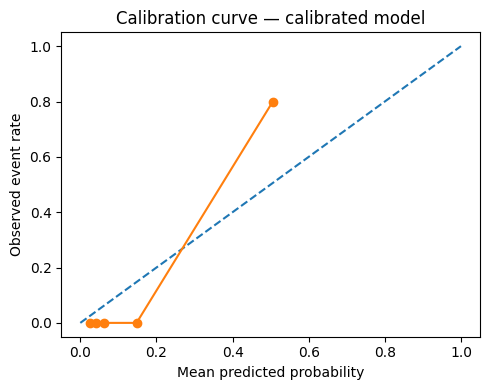

In [4]:
cal_bins = calibration_summary(y_test, cal_prob)["calibration_bins"]
cal_bins.to_csv(REPORTS / "calibration_bins.csv", index=False)

plt.figure(figsize=(5, 4))
plt.plot([0, 1], [0, 1], linestyle="--")
plt.plot(cal_bins["mean_predicted_probability"], cal_bins["observed_event_rate"], marker="o")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed event rate")
plt.title("Calibration curve — calibrated model")
plt.tight_layout()
plt.savefig(REPORTS / "calibration_curve.png", dpi=160)
plt.show()

## 4. Bootstrap prediction intervals and confidence logic

In [5]:
mean_prob, ci_low, ci_high = bootstrap_prediction_intervals(
    estimator=base_model,
    X_train=X_train_full,
    y_train=y_train_full,
    X_eval=X_test,
    n_bootstraps=40,
    random_state=42,
)
ci_width = ci_high - ci_low
miss = missingness_penalty(X_test)
conf_scores = confidence_score_from_signals(mean_prob, miss, ci_width=ci_width)
conf_labels = confidence_label(conf_scores)

confidence_index = compute_index_table(
    sample_ids=X_test.index,
    probabilities=mean_prob,
    confidence_labels=conf_labels,
    confidence_scores=conf_scores,
    ci_lower=ci_low,
    ci_upper=ci_high,
)
confidence_index["true_label"] = y_test.loc[confidence_index["sample_id"]].values
confidence_index["missingness_rate"] = miss
confidence_index["ci_width"] = ci_width
confidence_index.to_csv(REPORTS / "confidence_logic_examples.csv", index=False)
confidence_index.sort_values("index_score", ascending=False).head(10)

/opt/pyvenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/pyvenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/pyvenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to

/opt/pyvenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/pyvenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/pyvenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to

,sample_id,probability,index_score,risk_band,confidence_label,confidence_score,decision_gate,ci_lower,ci_upper,true_label,missingness_rate,ci_width
2,S076,0.749285,75,Red,Low,0.410211,Clinician review required: low confidence,0.385316,0.930714,1,0.000000,0.545398
22,S061,0.626330,63,Amber,Low,0.254468,Clinician review required: low confidence,0.240630,0.929187,1,0.020833,0.688556
5,S081,0.582095,58,Amber,Low,0.220768,Clinician review required: low confidence,0.197873,0.907324,1,0.008333,0.709450
4,S008,0.540273,54,Amber,Low,0.180785,Clinician review required: low confidence,0.209634,0.857312,1,0.020833,0.647678
8,S056,0.517433,52,Amber,Low,0.168988,Clinician review required: low confidence,0.157655,0.757992,0,0.008333,0.600337
13,S060,0.211006,21,Green,Moderate,0.515442,Routine clinician review,0.057100,0.407687,0,0.016667,0.350587
14,S032,0.182370,18,Green,Moderate,0.544184,Routine clinician review,0.036998,0.417785,0,0.012500,0.380787
11,S082,0.184476,18,Green,Moderate,0.552282,Routine clinician review,0.054834,0.402970,0,0.012500,0.348136
0,S053,0.148397,15,Green,Moderate,0.621263,Routine clinician review,0.031331,0.320977,0,0.012500,0.289646
1,S001,0.142684,14,Green,Moderate,0.630402,Routine clinician review,0.014632,0.307171,0,0.008333,0.292539


## 5. Clinical safety routing summary

This is the part hiring teams care about: the model does not silently produce an answer. It routes red or uncertain outputs to clinician review.

In [6]:
routing_summary = (
    confidence_index.assign(review_required=lambda d: d["decision_gate"].str.contains("required", case=False))
    .groupby(["risk_band", "confidence_label", "review_required"])
    .size()
    .reset_index(name="n")
)
routing_summary.to_csv(REPORTS / "clinical_routing_summary.csv", index=False)
routing_summary

,risk_band,confidence_label,review_required,n
0,Amber,Low,True,4
1,Green,High,False,12
2,Green,Moderate,False,7
3,Red,Low,True,1


## 6. What this notebook demonstrates

This notebook demonstrates confidence-aware clinical AI: calibration, uncertainty intervals, missingness-aware confidence scoring, and explicit clinician-review gates.